## 1. Load and inspect the data

In [170]:
# pandas for tables, numpy for numeric helpers
import pandas as pd
import numpy as np

In [171]:
# load the house prices competition files (they must sit in the same folder as this notebook)
# train has the target SalePrice; test does not
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')


In [172]:
# first five rows: a quick look at the columns and value types
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [173]:
# shape = (rows, columns): 1460 houses and 81 columns
train.shape

(1460, 81)

In [174]:
# summary statistics of the numeric columns (count, mean, std, min, quartiles, max)
# count below 1460 means that column has missing values (for example LotFrontage)
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [175]:
# dtypes and non-null counts per column; shows which columns are numeric and which are text
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [176]:
# list of all column names
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## 2. Missing values and cleaning

In [177]:
# missing values per column; LotFrontage has 259, and many categorical columns have gaps too
train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [178]:
# LotFrontage is numeric, so fill with the median (robust to outliers)
# alley is almost entirely missing (NaN here means 'no alley access'), so it carries little information and is dropped
train['LotFrontage']=train['LotFrontage'].fillna(train['LotFrontage'].median())
train=train.drop('Alley',axis=1)

In [179]:
# re-check; the nulls left are in categorical columns where NaN means 'feature absent' (no pool, no fence, no fireplace...)
# get_dummies below gives those rows all-zero dummies, which works as a 'none' category
train.isnull().sum()


Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 80, dtype: int64

## 3. Encode categorical columns

In [180]:
# find the text (categorical) columns so they can be one-hot encoded
# pandas 4 warns that select_dtypes('object') will change; use 'str' to silence it
cat=train.select_dtypes('object').columns
print(cat)

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')


C:\Users\Laiba\AppData\Local\Temp\ipykernel_17232\278240887.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat=train.select_dtypes('object').columns


In [181]:
# duplicate rows would inflate the data; 0 means nothing to remove
train.duplicated().sum()

np.int64(0)

In [182]:
# one-hot encode every categorical column; drop_first=True avoids the dummy variable trap (perfect multicollinearity)
# dtype=int gives 0/1 instead of True/False
# note: the models later in this notebook use only 12 numeric columns, so these dummies are used for the correlation check but not for fitting
train=pd.get_dummies(train,columns=['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],drop_first=True,dtype=int)

In [183]:
# confirm the dummy columns were created
train.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,0,0,0,0,1,0,0,0,1,0


## 4. EDA: target and relationships

In [184]:
# distribution of the target: mean (about 181k) is above the median (163k), so prices are right-skewed
train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

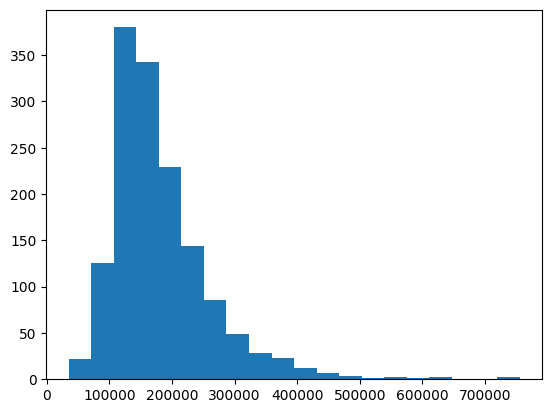

In [185]:
# histogram of SalePrice: a long right tail of expensive houses confirms the skew
import matplotlib.pyplot as plt

plt.hist(train['SalePrice'],bins=20)
plt.show()

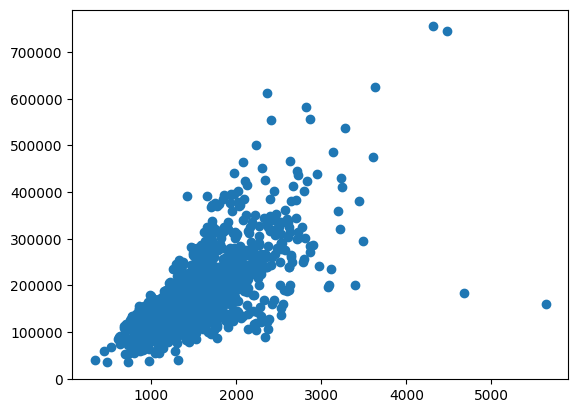

In [186]:
# scatter of living area vs price: roughly linear and increasing
# look for outliers such as very large houses with low prices
plt.scatter(
    train["GrLivArea"],
    train["SalePrice"]
)

plt.show()

In [187]:
# correlation of every numeric/dummy column with SalePrice, sorted high to low
# strongest: OverallQual (0.79), GrLivArea (0.71), GarageCars (0.64), GarageArea (0.62)
corr=train.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print(corr)

SalePrice            1.000000
OverallQual          0.790982
GrLivArea            0.708624
GarageCars           0.640409
GarageArea           0.623431
                       ...   
GarageType_Detchd   -0.354141
GarageFinish_Unf    -0.410608
BsmtQual_TA         -0.452394
KitchenQual_TA      -0.519298
ExterQual_TA        -0.589044
Name: SalePrice, Length: 245, dtype: float64


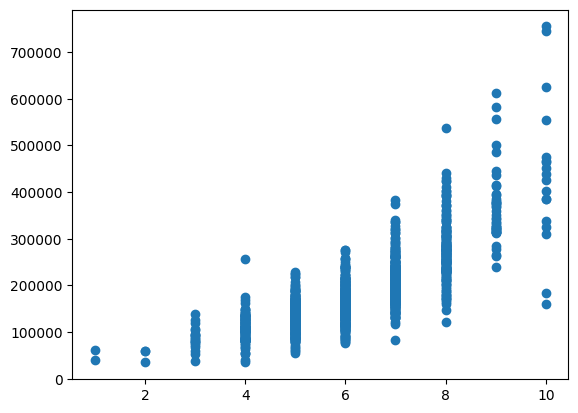

In [188]:
# overall quality vs price: price rises with quality, and the spread widens at higher quality
plt.scatter(train["OverallQual"], train["SalePrice"])
plt.show()

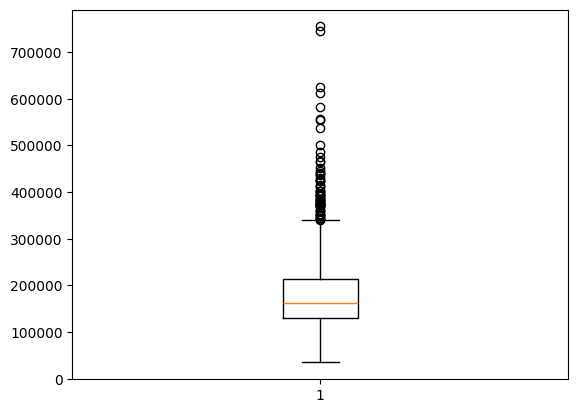

In [189]:
# boxplot of SalePrice: dots above the upper whisker are outliers (expensive houses)
plt.boxplot(train['SalePrice'])

plt.show()

## 5. Feature selection

In [190]:
# candidate features picked from the strongest correlations with SalePrice
# the commented block is an earlier, shorter list kept for reference
# correlation matrix among the chosen features helps spot multicollinearity (features that carry the same information)
# features = [
#     "OverallQual",
#     "GrLivArea",
#     "GarageCars",
#     "GarageArea"
# ]

features=[
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt",
    "YearRemodAdd",
    "FullBath",
    "TotRmsAbvGrd",
    "Fireplaces",
    "MasVnrArea",
    "BsmtFinSF1"
]

print(train[features].corr())

              OverallQual  GrLivArea  GarageCars  TotalBsmtSF  1stFlrSF  \
OverallQual      1.000000   0.593007    0.600671     0.537808  0.476224   
GrLivArea        0.593007   1.000000    0.467247     0.454868  0.566024   
GarageCars       0.600671   0.467247    1.000000     0.434585  0.439317   
TotalBsmtSF      0.537808   0.454868    0.434585     1.000000  0.819530   
1stFlrSF         0.476224   0.566024    0.439317     0.819530  1.000000   
YearBuilt        0.572323   0.199010    0.537850     0.391452  0.281986   
YearRemodAdd     0.550684   0.287389    0.420622     0.291066  0.240379   
FullBath         0.550600   0.630012    0.469672     0.323722  0.380637   
TotRmsAbvGrd     0.427452   0.825489    0.362289     0.285573  0.409516   
Fireplaces       0.396765   0.461679    0.300789     0.339519  0.410531   
MasVnrArea       0.411876   0.390857    0.364204     0.363936  0.344501   
BsmtFinSF1       0.239666   0.208171    0.224054     0.522396  0.445863   

              YearBuilt 

In [191]:
# GarageArea is dropped because it overlaps heavily with GarageCars (both measure garage size)
train=train.drop('GarageArea',axis=1)

In [192]:
# MasVnrArea has a few missing values; fill with the median
train["MasVnrArea"] = train["MasVnrArea"].fillna(
    train["MasVnrArea"].median()
)

In [193]:
# final feature matrix X and target y
# the commented block is the earlier shorter list
# features = [
#     "OverallQual",
#     "GrLivArea",
#     "GarageCars",
#     "TotalBsmtSF",
#     "1stFlrSF"
# ]

features=[
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt",
    "YearRemodAdd",
    "FullBath",
    "TotRmsAbvGrd",
    "Fireplaces",
    "MasVnrArea",
    "BsmtFinSF1"
]


X = train[features]
y = train["SalePrice"]

In [202]:
# confirm no missing values remain in the chosen features (models cannot handle NaN)
print(X.isnull().sum())

OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
1stFlrSF        0
YearBuilt       0
YearRemodAdd    0
FullBath        0
TotRmsAbvGrd    0
Fireplaces      0
MasVnrArea      0
BsmtFinSF1      0
dtype: int64


In [195]:
# column list after encoding and dropping, for reference
train.columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='str', length=244)

In [196]:
# the test file also has missing values (LotFrontage, MSZoning, ...)
# so test needs the same cleaning and the same feature columns before you predict on it
test.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

## 6. Train / validation split

In [197]:
# 80/20 train/validation split; random_state makes it reproducible
# no stratify because the target is continuous
# the validation set stays unseen while fitting
from sklearn.model_selection import train_test_split
X_train,X_val,y_train,y_val=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 7. Linear regression

**Logic: linear regression.** It fits `price = b0 + b1*x1 + b2*x2 + ...` by choosing the coefficients that minimise the sum of squared residuals (ordinary least squares). Each coefficient says how much the price changes for a one-unit change in that feature with the others held fixed. It is fast and interpretable, but assumes linearity, independent errors, constant error spread, roughly normal residuals and no strong multicollinearity (see the assumptions cell further down).

In [198]:
# fit ordinary least squares on the training set, then predict the validation set
from sklearn.linear_model import LinearRegression

lr=LinearRegression()

lr.fit(X_train,y_train)
lrpred=lr.predict(X_val)

In [199]:
# intercept = predicted price when all features are 0
# each coefficient = price change for a one-unit increase in that feature, other features held fixed (same order as the features list)
# example: about +19k per OverallQual point
# FullBath is negative (-2.5k) which is counter-intuitive; it overlaps with GrLivArea and TotRmsAbvGrd, so the coefficient is not a real negative effect
print('intercept: ',lr.intercept_)
print('coefficients: ',lr.coef_)

intercept:  -1228951.6913135222
coefficients:  [ 1.90456286e+04  3.71588299e+01  1.40592821e+04  7.04769124e+00
  9.27405700e+00  2.02922060e+02  3.87213581e+02 -2.51209708e+03
  1.98260723e+03  8.67373458e+03  2.18235056e+01  1.90056019e+01]


In [200]:
# MAE = average absolute error in dollars
# MSE = average squared error (penalises large errors, in dollars squared)
# RMSE = sqrt(MSE), back in dollars
# R2 = share of price variance explained (1 = perfect, 0 = no better than predicting the mean)
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

mae=mean_absolute_error(y_val,lrpred)
print('mae: ',mae)

mse=mean_squared_error(y_val,lrpred)
print('mse: ',mse)

rmse=np.sqrt(mse)
print('rmse: ',rmse)


r2=r2_score(y_val,lrpred)
print('r2 score: ',r2)

mae:  24419.83566887217
mse:  1444443577.3517685
rmse:  38005.83609594411
r2 score:  0.8116842050344196


### Cross-validation (linear regression)

In [203]:
# 5-fold cross-validation on the training data only
# the R2 scores range from 0.61 to 0.83, so the model is sensitive to which houses fall in a fold (outliers)
# the mean is lower than the single-split validation R2, a more honest estimate
from sklearn.model_selection import KFold,cross_val_score

kf=KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores=cross_val_score(
    lr,
    X_train,
    y_train,
    cv=kf,
    scoring='r2'
)

print('r2 scores: ',scores)
print("Mean R2:", scores.mean())
print("Std:", scores.std())



r2 scores:  [0.8263489  0.71824253 0.61156288 0.80875141 0.82635411]
Mean R2: 0.7582519651549297
Std: 0.08359872249134057


## 8. Polynomial regression

In [214]:
# switch to a smaller 5-feature set for polynomial regression (degree 2 of 12 features would create 90 terms)
# the commented line is an earlier one-feature attempt that performed badly
# X and y are overwritten here; the same random_state gives the same rows in train and validation as before
# the models after the polynomial section still use X_train / X_val from the 12-feature split
# X = train[['GrLivArea']] very worse pef
features3 = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "1stFlrSF"
]
X=train[features3]
y=train['SalePrice']

X_t2,X_v2,y_t2,y_v2=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Logic: polynomial regression.** It adds squared terms and products of the features (degree 2) and then fits an ordinary linear regression on them. The model can now curve and capture interactions, such as quality combined with size, while still being linear in its coefficients. Higher degrees fit the training data better but overfit quickly.

In [215]:
# degree=2 adds squares and pairwise products (for example OverallQual * GrLivArea), so the model can bend and capture interactions
# include_bias=False because LinearRegression already has an intercept
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(
    degree=2,
    include_bias=False
)

In [216]:
# fit_transform on train, transform on validation (nothing is learned from validation)
X_train_poly=poly.fit_transform(X_t2)
X_val_poly=poly.transform(X_v2)

In [217]:
# a linear model on the expanded features = polynomial regression
poly_model=LinearRegression()

poly_model.fit(
    X_train_poly,
    y_t2
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [218]:
# predict the validation set
polypred=poly_model.predict(
    X_val_poly
)

In [219]:
# same four metrics as before, now for the polynomial model
mae=mean_absolute_error(y_v2,polypred)
print('mae: ',mae)

mse=mean_squared_error(y_v2,polypred)
print('mse: ',mse)

rmse=np.sqrt(mse)
print('rmse: ',rmse)


r2=r2_score(y_v2,polypred)
print('r2 score: ',r2)

mae:  21731.49208570999
mse:  1091082408.522653
rmse:  33031.536575258695
r2 score:  0.8577528022862568


In [221]:
# pipeline = expand then fit, so the polynomial features are rebuilt inside every CV fold
# 5-fold CV on the training split; compare with the linear regression CV above
from sklearn.pipeline import Pipeline

poly_pipeline= Pipeline([
    ('poly',PolynomialFeatures(degree=2,include_bias=False)),
    ('lr',LinearRegression())
])

kf=KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores=cross_val_score(
    poly_pipeline,
    X_t2,
    y_t2,
    cv=kf,
    scoring='r2'
)

print("R2 scores:", scores)
print("Mean R2:", scores.mean())
print("Std:", scores.std())

R2 scores: [0.85812457 0.65486549 0.78456991 0.85465278 0.82630602]
Mean R2: 0.7957037522958943
Std: 0.07518939239786658


Degree-2 Polynomial Regression performed better than Multiple Linear Regression because it achieved a higher validation R² and a higher mean cross-validation R², while also having a slightly lower CV standard deviation.

linear regression assumptions:

1. linearity:
Linearity means there should be a linear relationship between the independent variables and the dependent variable.

2. independence:
Independence means each observation should be independent, and one observation should not influence another.

3. Homoscedasticity.
The prediction errors should have a similar spread everywhere.

check by :
residuals = y_val - lrpred

plt.scatter(lrpred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

4. Normality of residuals.
Normality of residuals means the prediction errors should be approximately normally distributed around zero.

check by: 
residuals = y_val - lrpred

plt.hist(residuals, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

5. No Perfect Multicollinearity.
Two input features should not be almost the same information.

6. No Autocorrelation.
one prediction error should not depend on the previous prediction error.

7. Additivity.
The total effect on y should be the sum of the individual effects of the features.

A problem occurs when the effect of one feature depends strongly on another feature.

## 9. Random forest regressor

**Logic: random forest regressor.** Many decision trees are trained on random bootstrap samples of the rows, with a random subset of features considered at each split. Each tree predicts a price and the forest returns the **average**. Averaging many different trees lowers variance, and trees handle non-linearity and interactions automatically without scaling.

In [222]:
# n_estimators=100 trees; max_depth=10 limits tree size to reduce overfitting; min_samples_split=2 is the default
# no scaling needed for trees
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [223]:
# regression forest prediction = average of all trees' predictions
rfpred=rf.predict(X_val)

In [224]:
# validation metrics for the random forest
mae=mean_absolute_error(y_val,rfpred)
print('mae: ',mae)

mse=mean_squared_error(y_val,rfpred)
print('mse: ',mse)

rmse=np.sqrt(mse)
print('rmse: ',rmse)


r2=r2_score(y_val,rfpred)
print('r2 score: ',r2)

mae:  18749.176642068458
mse:  854630432.3623599
rmse:  29234.062878128312
r2 score:  0.8885796497727088


In [226]:
# 5-fold CV for the random forest on the training split

kf=KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores=cross_val_score(
    rf,
    X_train,
    y_train,
    cv=kf,
    scoring='r2'
)

print("R2 scores:", scores)
print("Mean R2:", scores.mean())
print("Std:", scores.std())

R2 scores: [0.87601168 0.7341251  0.79190637 0.87870539 0.85483177]
Mean R2: 0.8271160630490254
Std: 0.056048983352513536


## 10. Ridge regression

**Logic: ridge regression.** It is linear regression with an extra penalty `alpha * sum(coefficient^2)` (L2). The penalty shrinks coefficients toward zero (never exactly zero), which stabilises the model when features are correlated. `alpha` sets the strength, and features must be scaled.

In [230]:
# ridge and lasso penalise coefficient size, so features must be on the same scale
# fit the scaler on the training set only, then apply it to validation
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

scaler=StandardScaler()

x_trained_scaled=scaler.fit_transform(X_train)
x_val_scaled=scaler.transform(X_val)

In [235]:
# ridge = linear regression + L2 penalty (alpha * sum of squared coefficients)
# alpha=1 is the penalty strength
ridge=Ridge(alpha=1.0)

ridge.fit(x_trained_scaled,y_train)
ridgepred=ridge.predict(x_val_scaled)

In [236]:
# validation metrics for ridge
mae=mean_absolute_error(y_val,ridgepred)
print('mae: ',mae)

mse=mean_squared_error(y_val,ridgepred)
print('mse: ',mse)

rmse=np.sqrt(mse)
print('rmse: ',rmse)


r2=r2_score(y_val,ridgepred)
print('r2 score: ',r2)

mae:  24415.231448149796
mse:  1444538673.5159245
rmse:  38007.08714852961
r2 score:  0.8116718071048418


In [242]:
# pipeline keeps the scaler inside each CV fold so validation folds never influence the scaling
# the commented kf block is a duplicate of the KFold defined earlier
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
# kf=KFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )

scores=cross_val_score(
    ridge_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring='r2'
)

print("R2 scores:", scores)
print("Mean R2:", scores.mean())
print("Std:", scores.std())

R2 scores: [0.82627068 0.71844005 0.61190038 0.80879847 0.82631012]
Mean R2: 0.758343941615258
Std: 0.08344715829761186


## 11. Lasso regression

**Logic: lasso regression.** It adds the penalty `alpha * sum(|coefficient|)` (L1). Unlike ridge, it can push some coefficients exactly to zero, so it also performs feature selection. It needs scaled features, like ridge.

In [258]:
# lasso = linear regression + L1 penalty (alpha * sum of absolute coefficients); it can shrink coefficients exactly to 0
from sklearn.linear_model import Lasso

lasso=Lasso(alpha=1)
lasso.fit(x_trained_scaled,y_train)

lassopred=lasso.predict(x_val_scaled)

In [259]:
# validation metrics for lasso
mae=mean_absolute_error(y_val,lassopred)
print('mae: ',mae)

mse=mean_squared_error(y_val,lassopred)
print('mse: ',mse)

rmse=np.sqrt(mse)
print('rmse: ',rmse)


r2=r2_score(y_val,lassopred)
print('r2 score: ',r2)

mae:  24419.6424111359
mse:  1444456624.6739135
rmse:  38006.00774448578
r2 score:  0.8116825040217388


In [ ]:
# 5-fold CV for lasso with scaling inside the pipeline
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=1))
])
# kf=KFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )

scores=cross_val_score(
    lasso_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring='r2'
)

print("R2 scores:", scores)
print("Mean R2:", scores.mean())
print("Std:", scores.std())

R2 scores: [0.82634843 0.71824299 0.61156562 0.80875257 0.82635382]
Mean R2: 0.7582526846214139
Std: 0.08359773380504855


## Summary of results

Validation set = 20% of the training rows (292 houses). CV = 5-fold on the training split.

| model | features | MAE ($) | RMSE ($) | validation R2 | CV R2 (mean +/- std) |
|---|---|---|---|---|---|
| linear regression | 12 | 24,420 | 38,006 | 0.812 | 0.758 +/- 0.084 |
| polynomial (degree 2) | 5 | 21,731 | 33,032 | 0.858 | 0.796 +/- 0.075 |
| random forest | 12 | 18,749 | 29,234 | 0.889 | 0.827 +/- 0.056 |
| ridge (alpha=1) | 12 | 24,415 | 38,007 | 0.812 | 0.758 +/- 0.083 |
| lasso (alpha=1) | 12 | 24,420 | 38,006 | 0.812 | 0.758 +/- 0.084 |

**Reading the table**
- The **random forest is best on every metric** and also has the smallest fold-to-fold spread, which fits the non-linear, interaction-heavy structure of house prices.
- **Linear, ridge and lasso are practically identical** (R2 0.812 for all three). With alpha=1 the penalty is tiny compared with squared errors measured in dollars, so the regularisation has almost no effect. Larger alphas (for example chosen with `RidgeCV` / `LassoCV`) are needed to see a difference.
- The polynomial model beats plain linear regression, but it uses 5 features while the linear model uses 12, so the two are not an exact like-for-like comparison.
- Validation R2 is higher than the CV mean for every model, which suggests this particular validation split is a little easier than average; the CV mean is the more honest estimate.